<a href="https://colab.research.google.com/github/Varshini151205/DL/blob/main/DL8ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving dog.jpg to dog.jpg


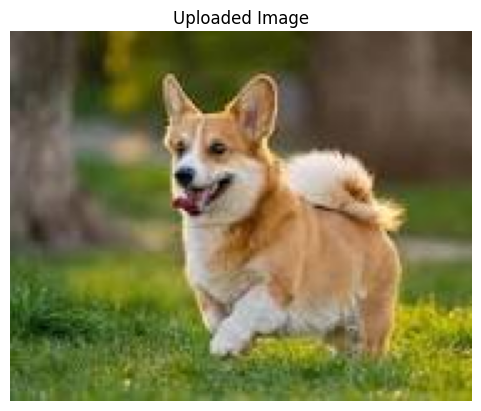

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0



 Top-5 Predictions:

Cardigan: 0.6275
Pembroke: 0.3585
basenji: 0.0053
dingo: 0.0050
Eskimo dog: 0.0011

 Top-1 Prediction:
Cardigan (0.6275)


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload image manually
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# 2. Load image
image = Image.open(image_path).convert('RGB')

# 3. Show image
plt.imshow(image)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# 4. Load pretrained VGG16 model
model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg16', pretrained=True)
model.eval()

# 5. Preprocess image
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)

# 6. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
input_batch = input_batch.to(device)

# 7. Prediction
with torch.no_grad():
    output = model(input_batch)

# 8. Convert to probabilities
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# 9. Load ImageNet labels
import requests
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
classes = requests.get(labels_url).text.splitlines()

# 10. Top-5 predictions
top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\n Top-5 Predictions:\n")
for i in range(top5_prob.size(0)):
    print(f"{classes[top5_catid[i]]}: {top5_prob[i].item():.4f}")

# 11. Top-1 prediction
print("\n Top-1 Prediction:")
print(f"{classes[top5_catid[0]]} ({top5_prob[0].item():.4f})")

Saving dog.jpg to dog (1).jpg


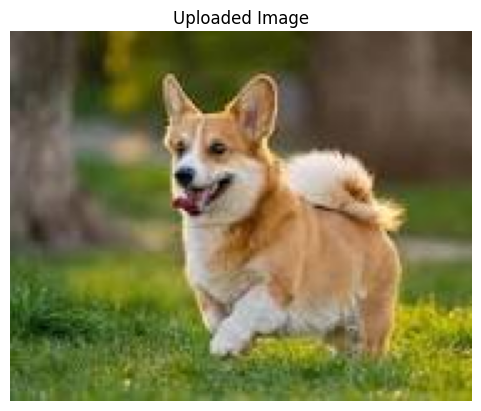

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]



 Top-5 Predictions:

Pembroke: 0.5064
Cardigan: 0.4886
basenji: 0.0013
Norwich terrier: 0.0005
dhole: 0.0005

 Top-1 Prediction:
Pembroke (0.5064)


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload image manually
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# 2. Load image
image = Image.open(image_path).convert('RGB')

# 3. Show image
plt.imshow(image)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# 4. Load pretrained VGG16 model
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
model.eval()

# 5. Preprocess image
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)

# 6. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
input_batch = input_batch.to(device)

# 7. Prediction
with torch.no_grad():
    output = model(input_batch)

# 8. Convert to probabilities
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# 9. Load ImageNet labels
import requests
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
classes = requests.get(labels_url).text.splitlines()

# 10. Top-5 predictions
top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\n Top-5 Predictions:\n")
for i in range(top5_prob.size(0)):
    print(f"{classes[top5_catid[i]]}: {top5_prob[i].item():.4f}")

# 11. Top-1 prediction
print("\n Top-1 Prediction:")
print(f"{classes[top5_catid[0]]} ({top5_prob[0].item():.4f})")

In [ ]:
import torch
import torch.nn as nn   # ✅ ADD THIS

class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(ConvBlock, self).__init__()

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x

In [ ]:
class InceptionModule(nn.Module):

    def __init__(self, in_channels, f_1x1, f_3x3_r, f_3x3, f_5x5_r, f_5x5, f_pp):
        super(InceptionModule, self).__init__()

        self.branch1 = nn.Sequential(
            ConvBlock(in_channels, f_1x1, kernel_size=1, stride=1, padding=0)
        )

        self.branch2 = nn.Sequential(
            ConvBlock(in_channels, f_3x3_r, kernel_size=1, stride=1, padding=0),
            ConvBlock(f_3x3_r, f_3x3, kernel_size=3, stride=1, padding=1)
        )

        self.branch3 = nn.Sequential(
            ConvBlock(in_channels, f_5x5_r, kernel_size=1, stride=1, padding=0),
            ConvBlock(f_5x5_r, f_5x5, kernel_size=5, stride=1, padding=2)
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1, ceil_mode=True),
            ConvBlock(in_channels, f_pp, kernel_size=1, stride=1, padding=0)
        )

    def forward(self, x):
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)

        return torch.cat([branch1, branch2, branch3, branch4], 1)

In [ ]:
class InceptionAux(nn.Module):

    def __init__(self, in_channels, num_classes):
        super(InceptionAux, self).__init__()

        self.pool = nn.AdaptiveAvgPool2d((4,4))
        self.conv = nn.Conv2d(in_channels, 128, kernel_size=1, stride=1, padding=0)
        self.act = nn.ReLU()
        self.fc1 = nn.Linear(2048, 1024)
        self.dropout = nn.Dropout(0.7)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool(x)

        x = self.conv(x)
        x = self.act(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [ ]:
class GoogLeNet(nn.Module):

    def __init__(self, num_classes = 10):
        super(GoogLeNet, self).__init__()

        self.conv1 = ConvBlock(3, 64, kernel_size=7, stride=2, padding=3)
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=0, ceil_mode=True)
        self.conv2 = ConvBlock(64, 64, kernel_size=1, stride=1, padding=0)
        self.conv3 = ConvBlock(64, 192, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(3, stride=2, padding=0, ceil_mode=True)
        self.inception3A = InceptionModule(in_channels=192,
                                           f_1x1=64,
                                           f_3x3_r=96,
                                           f_3x3=128,
                                           f_5x5_r=16,
                                           f_5x5=32,
                                           f_pp=32)
        self.inception3B = InceptionModule(in_channels=256,
                                           f_1x1=128,
                                           f_3x3_r=128,
                                           f_3x3=192,
                                           f_5x5_r=32,
                                           f_5x5=96,
                                           f_pp=64)
        self.pool4 = nn.MaxPool2d(3, stride=2, padding=0, ceil_mode=True)
        self.inception4A = InceptionModule(in_channels=480,
                                           f_1x1=192,
                                           f_3x3_r=96,
                                           f_3x3=208,
                                           f_5x5_r=16,
                                           f_5x5=48,
                                           f_pp=64)
        self.inception4B = InceptionModule(in_channels=512,
                                           f_1x1=160,
                                           f_3x3_r=112,
                                           f_3x3=224,
                                           f_5x5_r=24,
                                           f_5x5=64,
                                           f_pp=64)
        self.inception4C = InceptionModule(in_channels=512,
                                           f_1x1=128,
                                           f_3x3_r=128,
                                           f_3x3=256,
                                           f_5x5_r=24,
                                           f_5x5=64,
                                           f_pp=64)
        self.inception4D = InceptionModule(in_channels=512,
                                           f_1x1=112,
                                           f_3x3_r=144,
                                           f_3x3=288,
                                           f_5x5_r=32,
                                           f_5x5=64,
                                           f_pp=64)
        self.inception4E = InceptionModule(in_channels=528,
                                           f_1x1=256,
                                           f_3x3_r=160,
                                           f_3x3=320,
                                           f_5x5_r=32,
                                           f_5x5=128,
                                           f_pp=128)
        self.pool5 = nn.MaxPool2d(3, stride=2, padding=0, ceil_mode=True)
        self.inception5A = InceptionModule(in_channels=832,
                                           f_1x1=256,
                                           f_3x3_r=160,
                                           f_3x3=320,
                                           f_5x5_r=32,
                                           f_5x5=128,
                                           f_pp=128)
        self.inception5B = InceptionModule(in_channels=832,
                                           f_1x1=384,
                                           f_3x3_r=192,
                                           f_3x3=384,
                                           f_5x5_r=48,
                                           f_5x5=128,
                                           f_pp=128)
        self.pool6 = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)

        self.aux4A = InceptionAux(512, num_classes)
        self.aux4D = InceptionAux(528, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool3(x)
        x = self.inception3A(x)
        x = self.inception3B(x)
        x = self.pool4(x)
        x = self.inception4A(x)

        aux1 = self.aux4A(x)

        x = self.inception4B(x)
        x = self.inception4C(x)
        x = self.inception4D(x)

        aux2 = self.aux4D(x)

        x = self.inception4E(x)
        x = self.pool5(x)
        x = self.inception5A(x)
        x = self.inception5B(x)
        x = self.pool6(x)
        x = torch.flatten(x,1)
        x = self.dropout(x)
        x = self.fc(x)

        return x, aux1, aux2

In [ ]:
def train_model(model, train_loader, val_loader, epochs=5):
    train_costs = []
    val_costs = []

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_costs.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_costs.append(val_loss)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    return train_costs, val_costs

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Transform (same as VGG input)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

val_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 39.8MB/s]


In [ ]:
train_costs, val_costs = train_model(model, train_loader, val_loader)

**Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)**

In [ ]:
pip install tensorflow matplotlib numpy

Enter image path: /content/dog.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


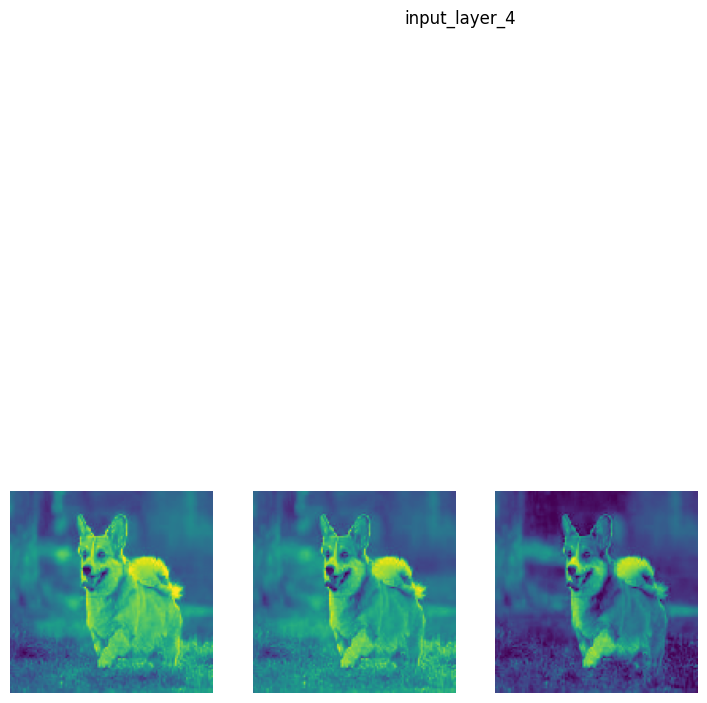

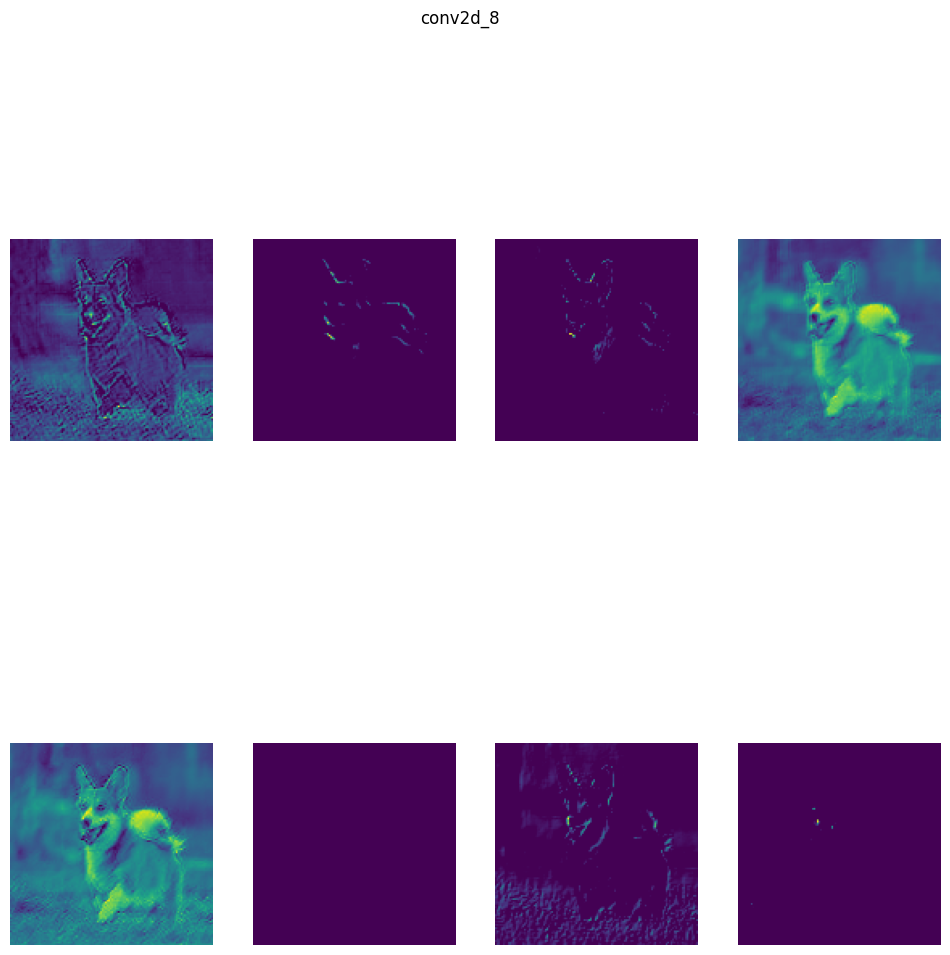

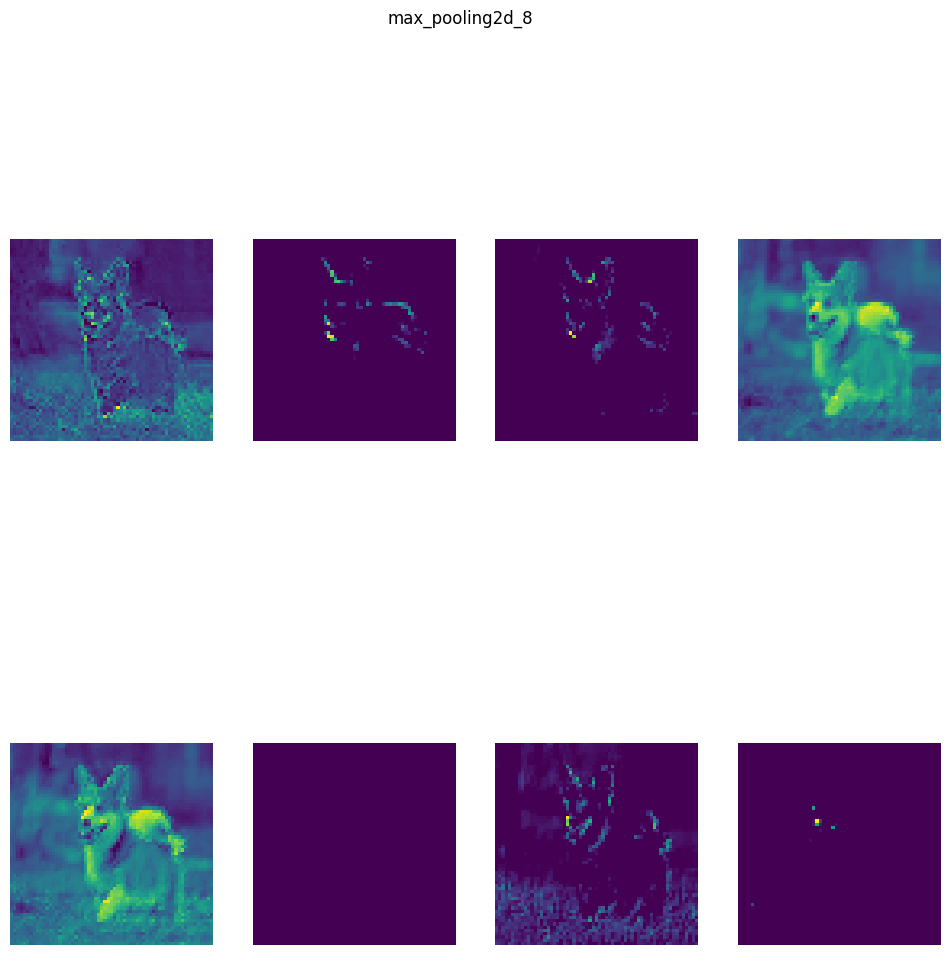

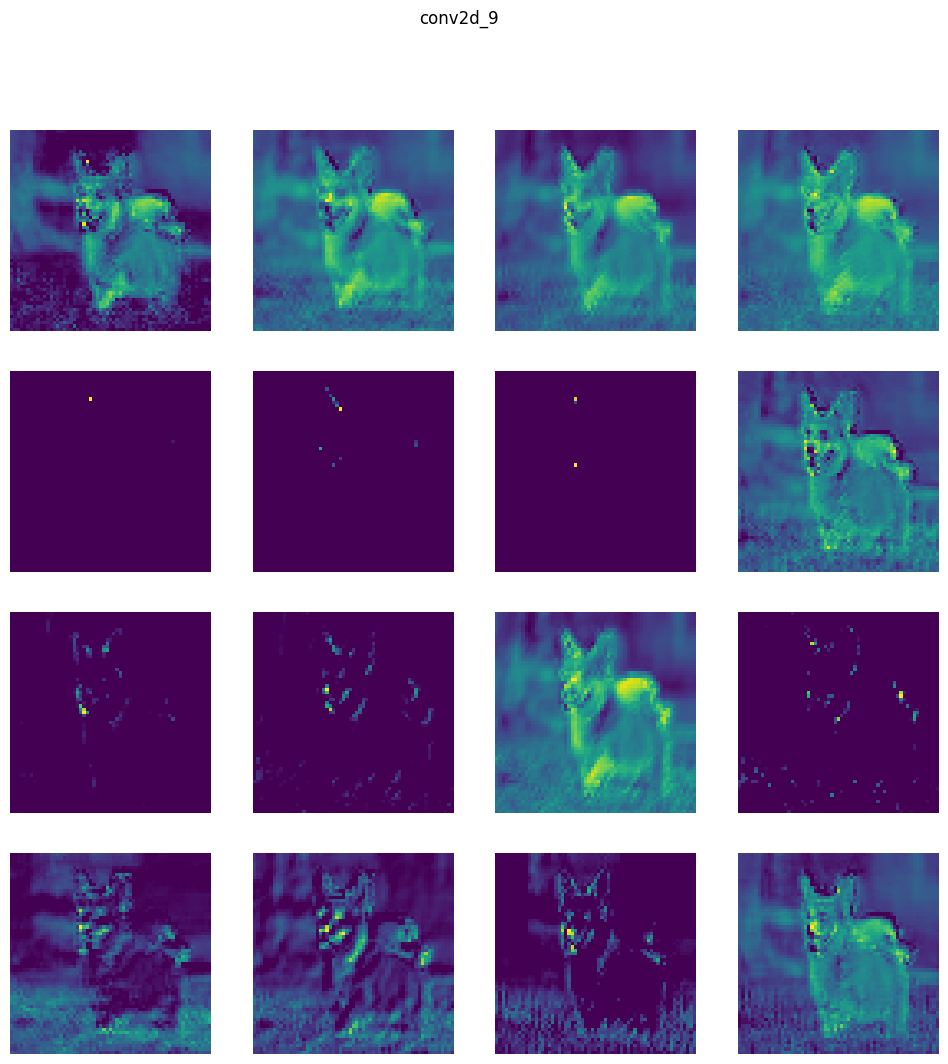

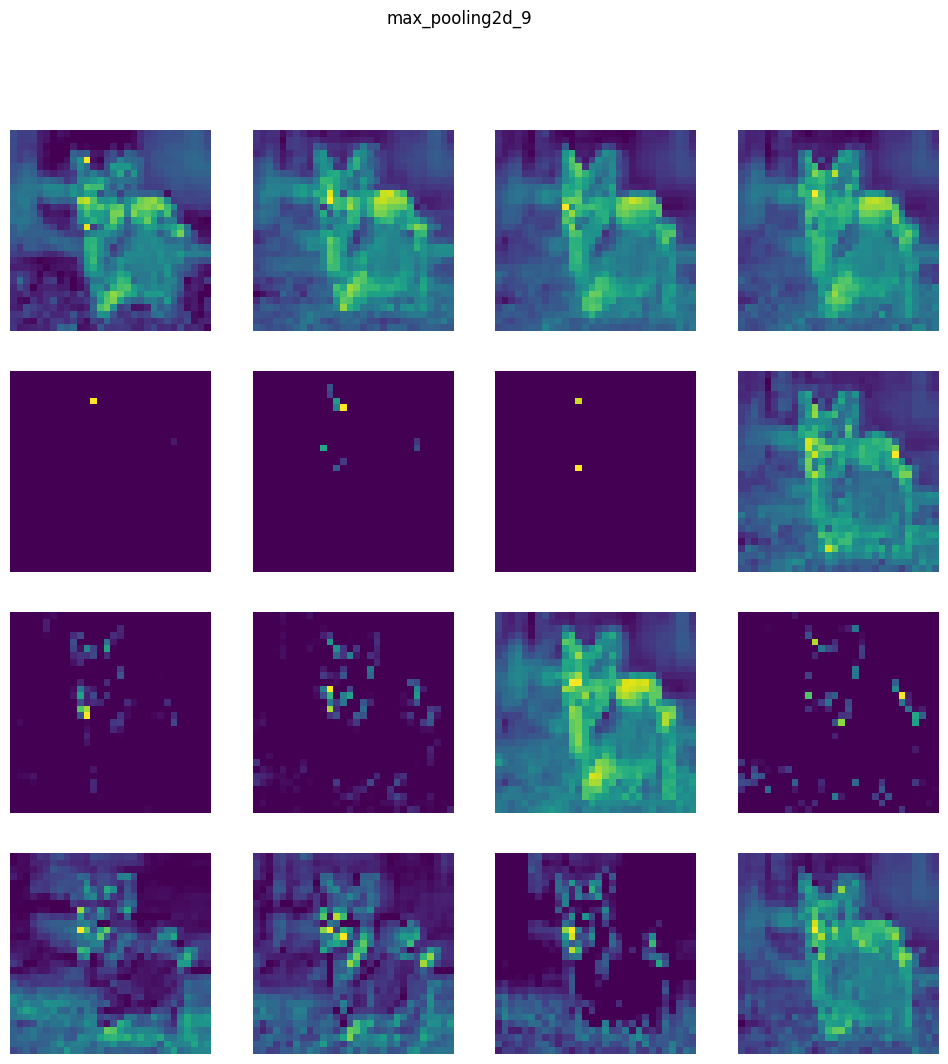

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = input("Enter image path: ")

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

inputs = tf.keras.Input(shape=(128,128,3))
x = tf.keras.layers.Conv2D(8, (3,3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(16, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)

model = tf.keras.Model(inputs=inputs, outputs=x)

layer_outputs = [layer.output for layer in model.layers]
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

activations = activation_model.predict(img_array)

layer_names = [layer.name for layer in model.layers]

for i, activation in enumerate(activations):
    layer_name = layer_names[i]
    feature_map = activation[0]
    num_filters = feature_map.shape[-1]
    cols = 4
    rows = num_filters // cols if num_filters >= cols else 1
    plt.figure(figsize=(12, 12))
    plt.suptitle(layer_name)
    for j in range(num_filters):
        plt.subplot(rows, cols, j+1)
        plt.imshow(feature_map[:, :, j], cmap='viridis')
        plt.axis('off')
    plt.show()

**Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)**

Enter image path: /content/dog.jpg


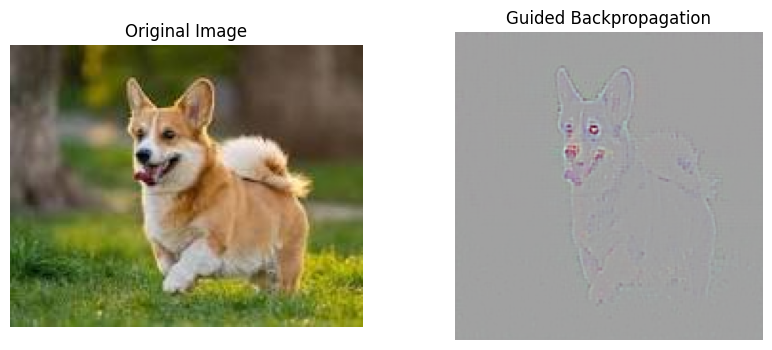

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

img_path = input("Enter image path: ")

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

model = tf.keras.applications.VGG16(weights='imagenet', include_top=True)

@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

img_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img_tensor)[0]

grads = grads.numpy()
grads = (grads - grads.min()) / (grads.max() - grads.min())

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image.load_img(img_path))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Guided Backpropagation")
plt.imshow(grads)
plt.axis('off')

plt.show()

**possible minimum and maximum computation**


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3386 - val_loss: 0.2715
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2678 - val_loss: 0.2653
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2648 - val_loss: 0.2640
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2639 - val_loss: 0.2633
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2633 - val_loss: 0.2630
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2631 - val_loss: 0.2627
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2624 - val_loss: 0.2600
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2569 - val_loss: 0.2534
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2513 - val_loss: 0.2485
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

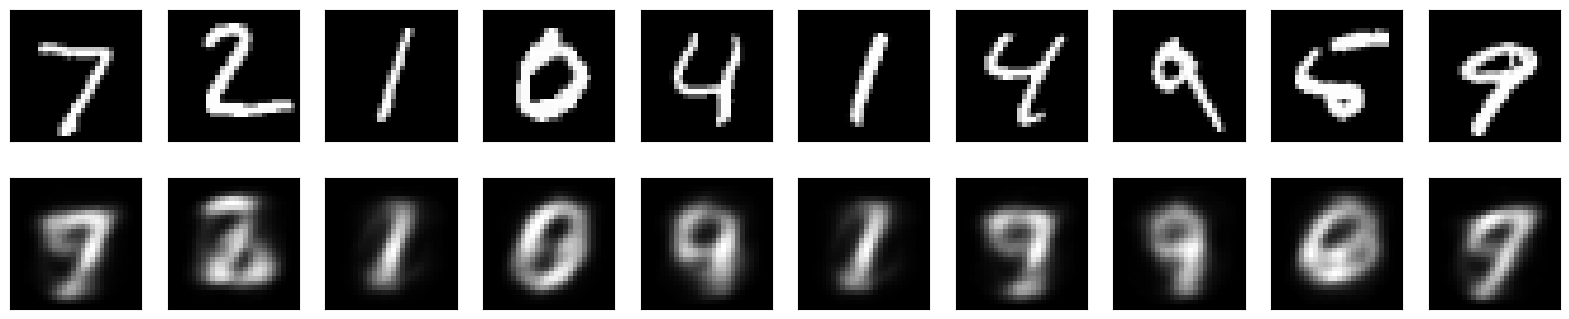

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))
input_dim=784
encoding_dim=32

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='sigmoid')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test,x_test))
decoded_imgs=autoencoder.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
 ax=plt.subplot(2,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
 ax=plt.subplot(2,n,i+1+n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2764 - val_loss: 0.1874
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1674 - val_loss: 0.1506
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1415 - val_loss: 0.1310
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1260 - val_loss: 0.1188
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1160 - val_loss: 0.1107
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1090 - val_loss: 0.1049
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1041 - val_loss: 0.1009
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1007 - val_loss: 0.0980
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0983 - val_loss: 0.0962
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0968 - val_loss: 0.0949
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0958 - val_loss: 0.0941
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

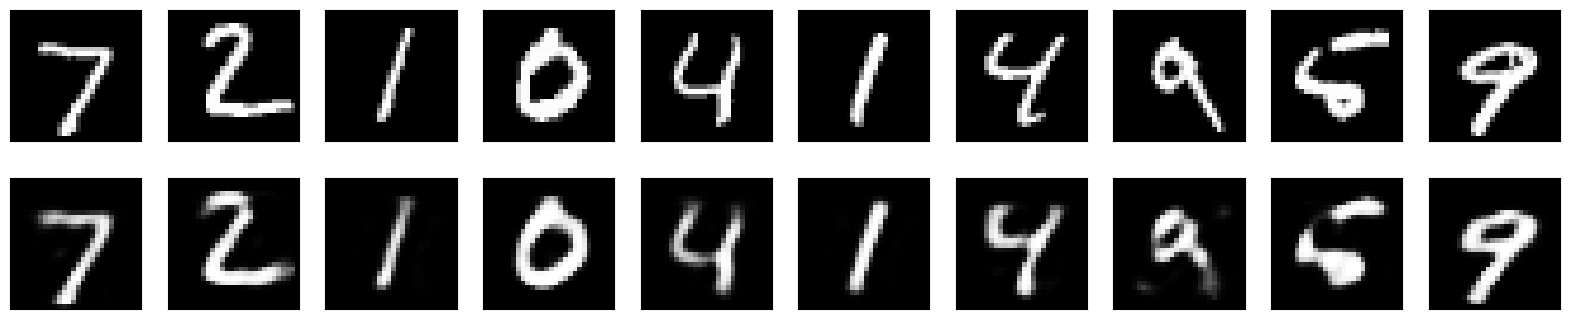

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))
input_dim=784
encoding_dim=32

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='relu')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test,x_test))
decoded_imgs=autoencoder.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
 ax=plt.subplot(2,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
 ax=plt.subplot(2,n,i+1+n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3919 - val_loss: 0.2923
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2795 - val_loss: 0.2721
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2694 - val_loss: 0.2672
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2664 - val_loss: 0.2653
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2650 - val_loss: 0.2643
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2643 - val_loss: 0.2638
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2639 - val_loss: 0.2634
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2636 - val_loss: 0.2632
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2634 - val_loss: 0.2631
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2633 - val_loss: 0.2629
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2632 - val_loss: 0.2628
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11m

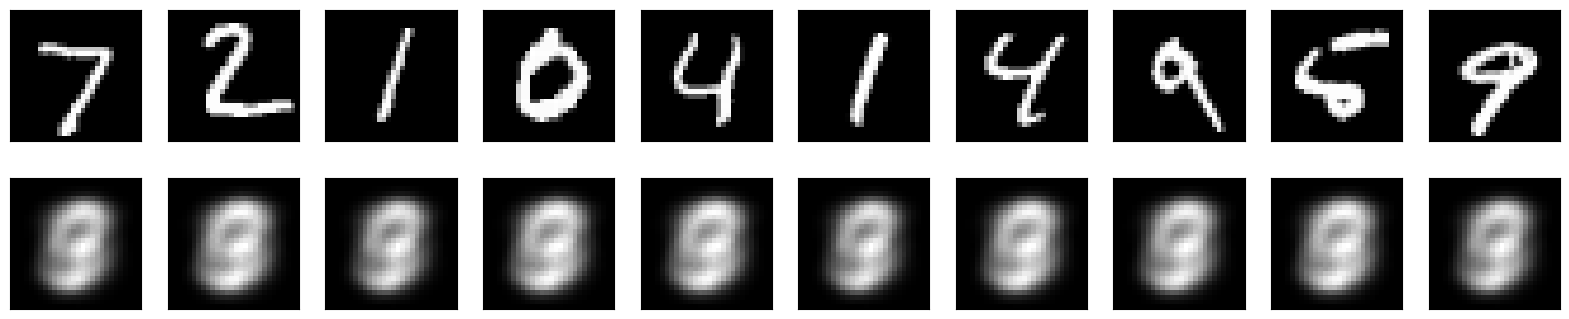

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))
input_dim=784
encoding_dim=16

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='sigmoid')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test,x_test))
decoded_imgs=autoencoder.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
 ax=plt.subplot(2,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
 ax=plt.subplot(2,n,i+1+n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.3651 - val_loss: 0.2811
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2716 - val_loss: 0.2664
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2650 - val_loss: 0.2637
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2635 - val_loss: 0.2629
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2630 - val_loss: 0.2626
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2629 - val_loss: 0.2625
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2628 - val_loss: 0.2625
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2628 - val_loss: 0.2625
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2628 - val_loss: 0.2625
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2628 - val_loss: 0.2625
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2628 - val_loss: 0.2625
Epoch 12/20
1875/1875 ━━━━━━━━

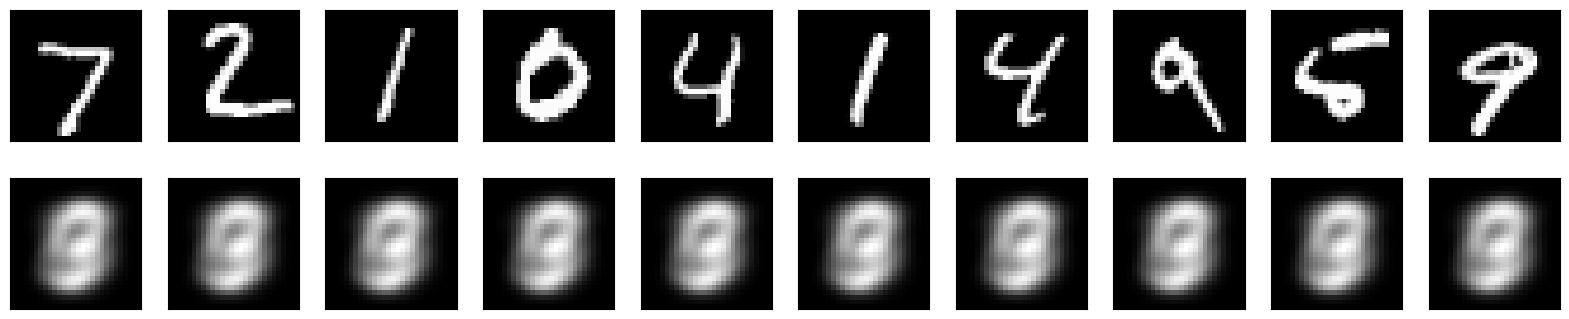

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))
input_dim=784
encoding_dim=2

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='sigmoid')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=20,batch_size=32,shuffle=True,validation_data=(x_test,x_test))
decoded_imgs=autoencoder.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
 ax=plt.subplot(2,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
 ax=plt.subplot(2,n,i+1+n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
plt.show()

when the batch size is small and encoder size is small it is more blurred and they are less accurate

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3380 - val_loss: 0.2715
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2678 - val_loss: 0.2654
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2648 - val_loss: 0.2639
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2639 - val_loss: 0.2634
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2633 - val_loss: 0.2630
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2632 - val_loss: 0.2630
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2631 - val_loss: 0.2627
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2630 - val_loss: 0.2627
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2609 - val_loss: 0.2580
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2

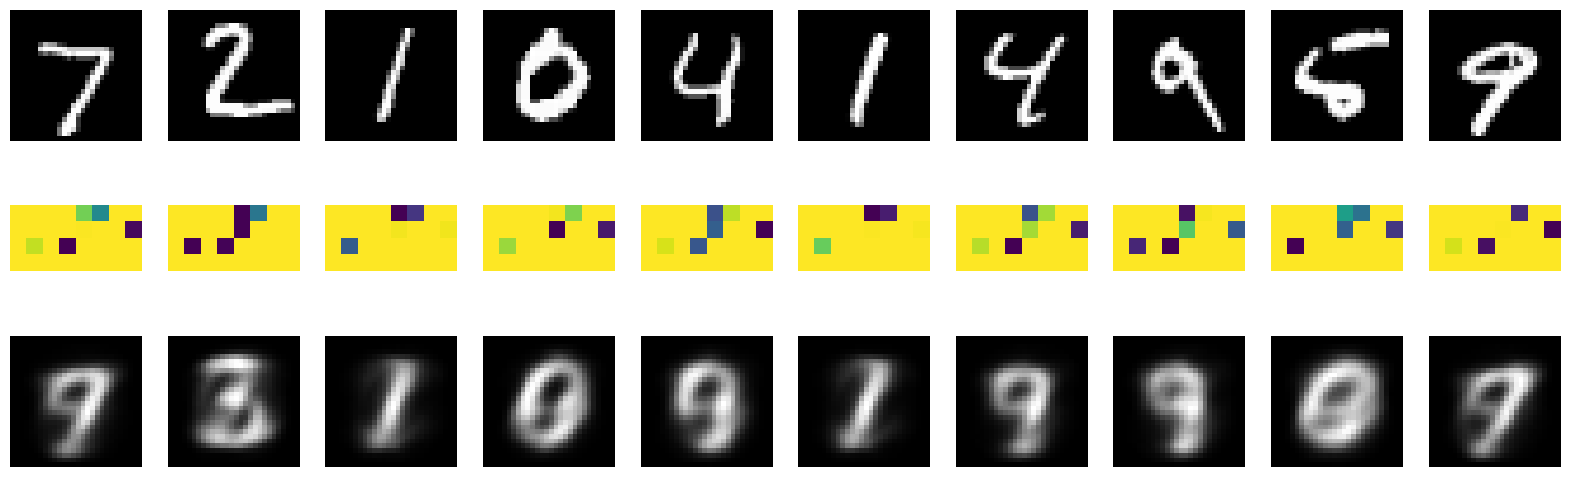

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))

input_dim=784
encoding_dim=32

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='sigmoid')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
encoder=Model(input_layer,encoded)

encoded_input=Input(shape=(encoding_dim,))
decoder_layer=autoencoder.layers[-1]
decoder=Model(encoded_input,decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

encoded_imgs=encoder.predict(x_test)
decoded_imgs=decoder.predict(encoded_imgs)

n=10
plt.figure(figsize=(20,6))
for i in range(n):
 ax=plt.subplot(3,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

 ax=plt.subplot(3,n,i+1+n)
 plt.imshow(encoded_imgs[i].reshape(4,8),cmap='viridis')
 ax.axis('off')

 ax=plt.subplot(3,n,i+1+2*n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

plt.show()

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.3070 - val_loss: 0.2655
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2631 - val_loss: 0.2592
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2533 - val_loss: 0.2454
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2370 - val_loss: 0.2275
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2196 - val_loss: 0.2101
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2028 - val_loss: 0.1946
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1889 - val_loss: 0.1819
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1774 - val_loss: 0.1717
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1684 - val_loss: 0.1637
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1612 - val_loss: 0.1570
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1549 - val_loss: 0.1510
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

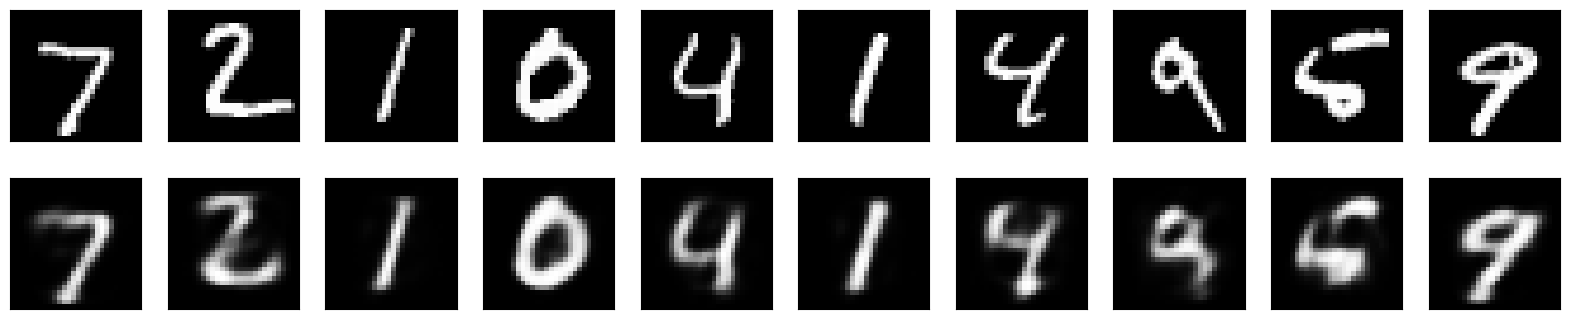

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))
input_dim=784
encoding_dim=64

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='sigmoid')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test,x_test))
decoded_imgs=autoencoder.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
 ax=plt.subplot(2,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
 ax=plt.subplot(2,n,i+1+n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
plt.show()

giving maximum dimension like 64 is giving the accurate data and minimum is 32

**both together code to find the difference adding noise to input and reducing the dimensions in autoencoder**

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2443 - val_loss: 0.1591
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1412 - val_loss: 0.1242
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1160 - val_loss: 0.1066
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1024 - val_loss: 0.0964
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0938 - val_loss: 0.0894
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0879 - val_loss: 0.0846
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0837 - val_loss: 0.0812
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0809 - val_loss: 0.0791
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0789 - val_loss: 0.0773
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0776 - val_loss: 0.0763
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3107 - val_loss: 0.2201
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s

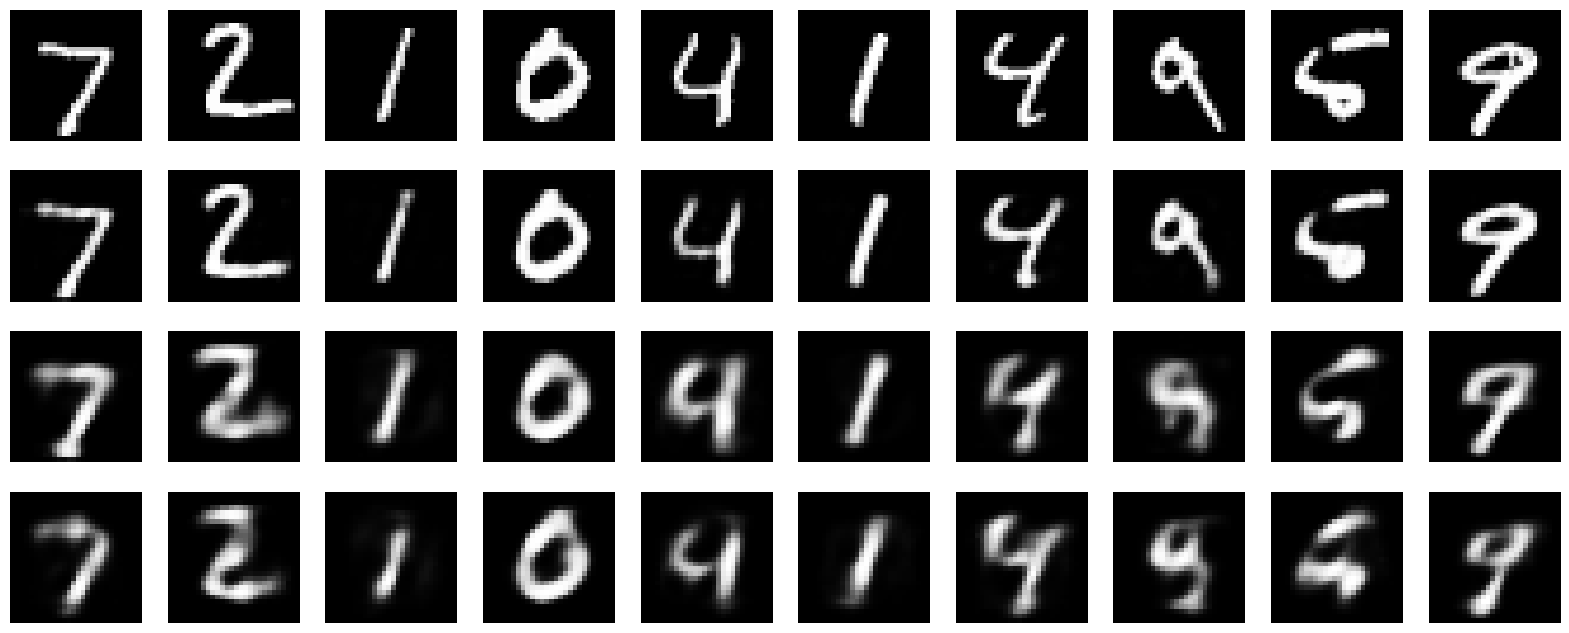

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.

x_train=x_train.reshape((len(x_train),784))
x_test=x_test.reshape((len(x_test),784))

noise_factor=0.5
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.)

input_img=Input(shape=(784,))
encoded1=Dense(64,activation='relu')(input_img)
decoded1=Dense(784,activation='sigmoid')(encoded1)
autoencoder1=Model(input_img,decoded1)
autoencoder1.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder1.fit(x_train,x_train,epochs=10,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

input_img2=Input(shape=(784,))
encoded2=Dense(16,activation='relu')(input_img2)
decoded2=Dense(784,activation='sigmoid')(encoded2)
autoencoder2=Model(input_img2,decoded2)
autoencoder2.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder2.fit(x_train,x_train,epochs=10,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

input_img3=Input(shape=(784,))
encoded3=Dense(16,activation='relu')(input_img3)
decoded3=Dense(784,activation='sigmoid')(encoded3)
autoencoder3=Model(input_img3,decoded3)
autoencoder3.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder3.fit(x_train_noisy,x_train,epochs=10,batch_size=256,shuffle=True,validation_data=(x_test_noisy,x_test))

decoded1=autoencoder1.predict(x_test)
decoded2=autoencoder2.predict(x_test)
decoded3=autoencoder3.predict(x_test_noisy)

n=10
plt.figure(figsize=(20,8))
for i in range(n):
 ax=plt.subplot(4,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

 ax=plt.subplot(4,n,i+1+n)
 plt.imshow(decoded1[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

 ax=plt.subplot(4,n,i+1+2*n)
 plt.imshow(decoded2[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

 ax=plt.subplot(4,n,i+1+3*n)
 plt.imshow(decoded3[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 0.1790 - val_loss: 0.1186
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 0.1026 - val_loss: 0.0897
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 0.0848 - val_loss: 0.0793
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 0.0774 - val_loss: 0.0744
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0735 - val_loss: 0.0716
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


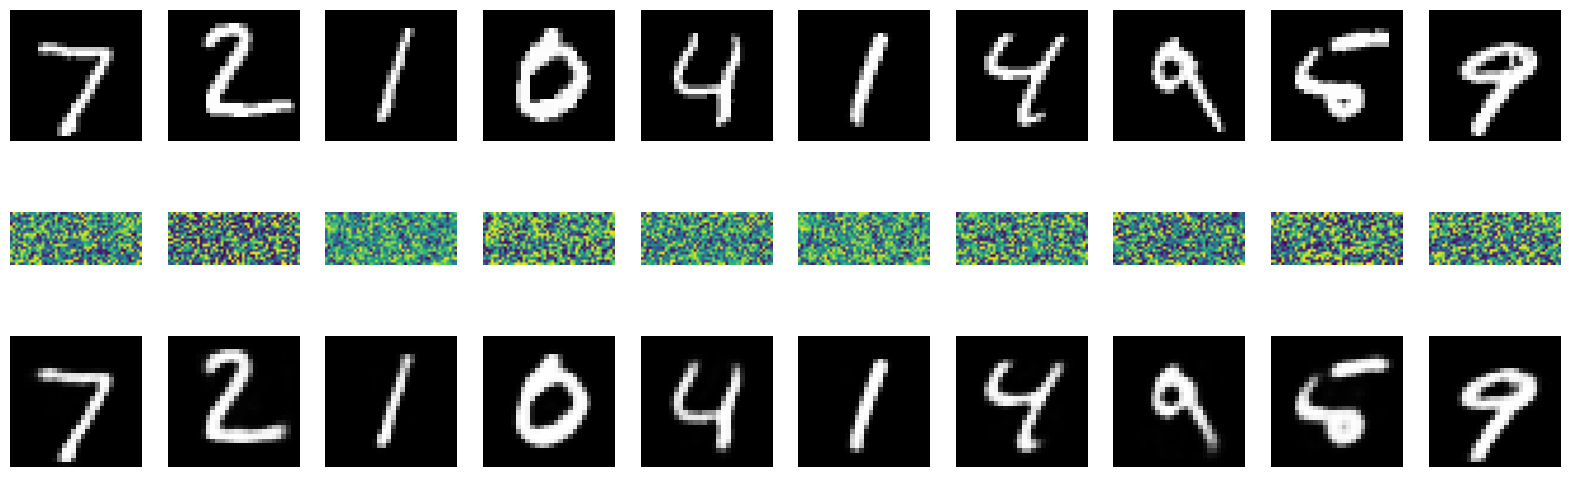

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))

input_dim=784
encoding_dim=1000

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='sigmoid')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
encoder=Model(input_layer,encoded)

encoded_input=Input(shape=(encoding_dim,))
decoder_layer=autoencoder.layers[-1]
decoder=Model(encoded_input,decoder_layer(encoded_input))

autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=5,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

encoded_imgs=encoder.predict(x_test)
decoded_imgs=decoder.predict(encoded_imgs)

n=10
plt.figure(figsize=(20,6))
for i in range(n):
 ax=plt.subplot(3,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

 ax=plt.subplot(3,n,i+1+n)
 plt.imshow(encoded_imgs[i].reshape(20,50),cmap='viridis')
 ax.axis('off')

 ax=plt.subplot(3,n,i+1+2*n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.axis('off')

plt.show()

**ZFNet**

Saving dog.jpeg to dog (3).jpeg


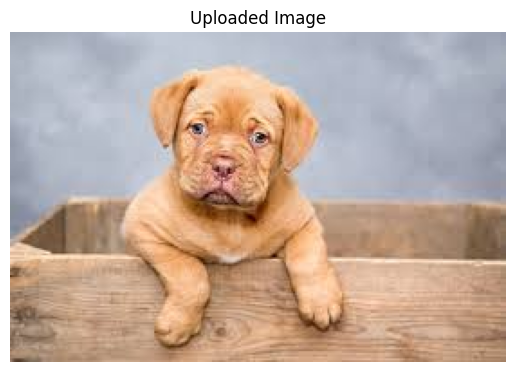


Top-5 Predictions (ZFNet - random weights):

grey whale: 0.0012
cliff dwelling: 0.0012
American black bear: 0.0012
screwdriver: 0.0012
cock: 0.0012


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import requests

# 1. Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 2. Load & display image
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# 3. ZFNet Model
class ZFNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 96, 7, 2),
            nn.ReLU(),
            nn.MaxPool2d(3, 2),

            nn.Conv2d(96, 256, 5, 2),
            nn.ReLU(),
            nn.MaxPool2d(3, 2),

            nn.AdaptiveAvgPool2d((5,5))  # Fix size issue
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*5*5, 1000)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# 4. Load model
model = ZFNet()
model.eval()

# 5. Preprocess image
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

input_tensor = transform(img).unsqueeze(0)

# 6. Prediction
with torch.no_grad():
    output = model(input_tensor)

# 7. Convert to probabilities
prob = torch.nn.functional.softmax(output[0], dim=0)

# 8. Load ImageNet labels
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
classes = requests.get(labels_url).text.splitlines()

# 9. Top-5 predictions
top5_prob, top5_catid = torch.topk(prob, 5)

print("\nTop-5 Predictions (ZFNet - random weights):\n")
for i in range(5):
    print(f"{classes[top5_catid[i]]}: {top5_prob[i].item():.4f}")

**ResNet**

Saving dog.jpeg to dog (5).jpeg


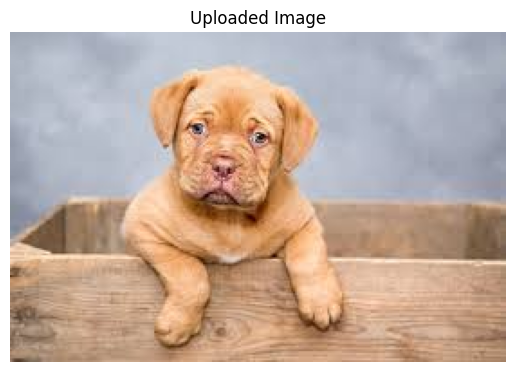

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s]



Top-5 Predictions (ResNet50):

bull mastiff: 0.3301
American Staffordshire terrier: 0.0566
vizsla: 0.0417
Staffordshire bullterrier: 0.0232
Sussex spaniel: 0.0159

Top-1 Prediction:
bull mastiff (0.3301)


In [ ]:
import torch
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 2. Load & display image
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# 3. Load pretrained ResNet50 (UPDATED WAY)
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

# 4. Preprocess image (BEST PRACTICE)
preprocess = weights.transforms()
input_tensor = preprocess(img).unsqueeze(0)

# 5. Prediction
with torch.no_grad():
    output = model(input_tensor)

# 6. Convert to probabilities
prob = torch.nn.functional.softmax(output[0], dim=0)

# 7. Get class labels
categories = weights.meta["categories"]

# 8. Top-5 predictions
top5_prob, top5_catid = torch.topk(prob, 5)

print("\nTop-5 Predictions (ResNet50):\n")
for i in range(5):
    print(f"{categories[top5_catid[i]]}: {top5_prob[i].item():.4f}")

# 9. Top-1 prediction
print("\nTop-1 Prediction:")
print(f"{categories[top5_catid[0]]} ({top5_prob[0].item():.4f})")

**google net**

Saving dog.jpeg to dog (7).jpeg


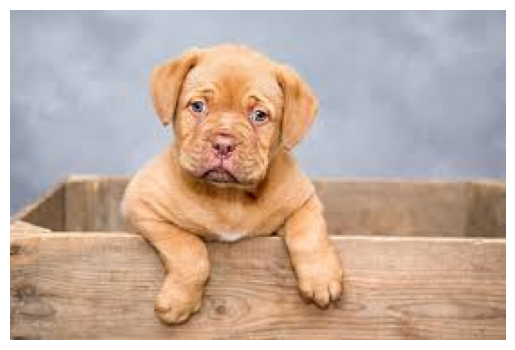


Top-5 Predictions:

bull mastiff 0.2607434093952179
vizsla 0.09679513424634933
Labrador retriever 0.09091287851333618
chow 0.06228114664554596
Chesapeake Bay retriever 0.04782090336084366


In [ ]:
import torch
from torchvision.models import googlenet, GoogLeNet_Weights
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load image
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.show()

# Load model
weights = GoogLeNet_Weights.DEFAULT
model = googlenet(weights=weights)
model.eval()

# Preprocess
preprocess = weights.transforms()
input_tensor = preprocess(img).unsqueeze(0)

# Prediction
with torch.no_grad():
    output = model(input_tensor)

# Probabilities
prob = torch.nn.functional.softmax(output[0], dim=0)

# Labels
categories = weights.meta["categories"]

# Top-5
top5_prob, top5_catid = torch.topk(prob, 5)

print("\nTop-5 Predictions:\n")
for i in range(5):
    print(categories[top5_catid[i]], top5_prob[i].item())